## Imports

In [1]:
%matplotlib inline

In [2]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from copy import deepcopy

import matplotlib.pyplot as plt
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go

In [3]:
from coretab.tree_plot_utils import plot_coreset, search_for_leaves_with_feature

## Import Dataset

In [ ]:
! pip install kagglehub

In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")

/Users/avivhadar/git/coretab/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
target_col = 'Class'
df = pd.read_csv(path + '/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## Train Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(target_col, axis=1), df[target_col], test_size=0.2, shuffle = True)

## Create Coreset

In [7]:
from coretab.coreset_algorithms import CoreTabDT, CoreTabXGB

In [8]:
coretab_dt = CoreTabDT(examples_to_keep=10_000)

In [9]:
X_coreset, y_coreset = coretab_dt.create_coreset(X_train, y_train)

## Compare Performance

In [10]:
# Regular XGBoost
model = xgb.XGBClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# Coreset XGBoost
model_coreset = xgb.XGBClassifier()
model_coreset.fit(X_coreset, y_coreset)
y_pred_coreset = model_coreset.predict(X_test)

# Training Enhancement Prediction
y_pred_test_coreset = coretab_dt.te_predict(X_test, model_coreset)

print(f"f1_score: {f1_score(y_test, y_pred)}")
print(f"f1_score_coreset: {f1_score(y_test, y_pred_coreset)}")
print(f"f1_score_te_coreset: {f1_score(y_test, y_pred_test_coreset)}")

f1_score: 0.8163265306122449
f1_score_coreset: 0.8955223880597015
f1_score_te_coreset: 0.8955223880597015


## Performace Gurantees

In [11]:
def print_precision_recall_guarantees(coretab_dt):
    df_0, df_1 = coretab_dt.get_guarantees(X_test, y_test)
    if df_1 is not None:
        df_vis = pd.concat([df_0.assign(metric='recall', delta_metric=df_0['delta_recall']),
                            df_1.assign(metric='precision', delta_metric=df_1['delta_precision'])])
    else:
        df_vis = df_0.assign(metric='recall', delta_metric=df_0['delta_recall'])
    df_vis.rename(columns={'delta_metric': 'Performace Decrease', 'percent_remained': 'Coreset size'}, inplace=True)
    fig = px.line(df_vis, x='Coreset size', y='Performace Decrease', title='Metrics Decrease vs. Coreset size',
              hover_data='group_id', color='metric', markers=True)
    fig.show()

In [12]:
# If there is a small amount of positive data we get all the positive examples so the precision guarantees are irrelevant
df_0, df_1 = coretab_dt.get_guarantees(X_test, y_test)
print_precision_recall_guarantees(coretab_dt)

## Explore the effect of features and nodes on the coreset

In [13]:
def get_coreset_with_nodes(coretab_dt: CoreTabDT, nodes_to_add: list):
    coretab_dt_copy = deepcopy(coretab_dt)
    coretab_dt_copy.hom_groups_candidates = [c for c in coretab_dt_copy.hom_groups_candidates if not c.key in nodes_to_add]
    coretab_dt_copy.hom_groups = dict()
    coretab_dt_copy.choose_groups(y_train)
    coretab_dt_copy.manually_added_nodes = nodes_to_add
    return coretab_dt_copy

def get_coreset_with_feature(coretab_dt: CoreTabDT, feature_to_add: str):
    nodes_with_feature = search_for_leaves_with_feature(coretab_dt, feature_to_add)
    return get_coreset_with_nodes(coretab_dt, nodes_with_feature)

In [14]:
def coretab_guarantees_without_leaves(coretab_dt: CoreTabDT, leaves_to_remove: list):
    coretab_copy = deepcopy(coretab_dt)
    coretab_copy.hom_groups_candidates = [c for c in coretab_copy.hom_groups_candidates if not c.key in leaves_to_remove]
    coretab_copy.hom_groups = dict()
    coretab_copy.choose_groups(y_train)
    return coretab_copy.get_guarantees(X_test, y_test)

def coretab_gurantees_without_feature(coretab_dt: CoreTabDT, feature_to_remove):
    leaves_with_feature = search_for_leaves_with_feature(coretab_dt, feature_to_remove)
    df0_new, df1_new = coretab_guarantees_without_leaves(coretab_dt, leaves_with_feature)
    return df0_new, df1_new

### Compare Guarantees

In [15]:
def compare_guarantees_with_nodes(coretab_dt: CoreTabDT, nodes_to_remove: list):
        
    df_0, df_1 = coretab_dt.get_guarantees(X_test, y_test)
    coretab_dt_with_nodes = get_coreset_with_nodes(coretab_dt, nodes_to_remove)
    df0_new, df1_new = coretab_dt_with_nodes.get_guarantees(X_test, y_test)
    
    df_vis = pd.concat([df_0.assign(df_data='all_data'), df0_new.assign(df_data='without_nodes')])
    df_vis.rename(columns={'delta_recall': 'Delta Recall', 'percent_remained': 'Coreset size'}, inplace=True)

    if df1_new is not None:
        df_vis_1 = pd.concat([df_1.assign(df_data='all_data'), df1_new.assign(df_data='without_feature')])
        df_vis_1.rename(columns={'delta_precision': 'Delta Precision', 'percent_remained': 'Coreset size'}, inplace=True)

    fig = make_subplots(rows=1, cols=2, subplot_titles=('Recall vs. Coreset size (Negative Data Reduction)', 'Precision vs. Coreset size (Positive Data Reduction)'))
    fig1 = px.line(df_vis, x='Coreset size', y='Delta Recall', title='Recall vs. Coreset size', hover_data='group_id', color='df_data', markers=True)
    if df1_new is not None:
        fig2 = px.line(df_vis_1, x='Coreset size', y='Delta Precision', title='Precision vs. Coreset size', hover_data='group_id', color='df_data', markers=True)
    
    for trace in fig1['data']:
        fig.add_trace(trace, row=1, col=1)

    # Add the second plotly express figure to the second subplot without showing the legend
    if df1_new is not None:
        for trace in fig2['data']:
            fig.add_trace(go.Scatter(trace, showlegend=False), row=1, col=2)

    fig.show()
    return coretab_dt_with_nodes

In [16]:
def compare_guarantees_with_feature(coretab_dt: CoreTabDT, feature):
    
    feature_nodes = search_for_leaves_with_feature(coretab_dt, feature)
    coretab_dt_with_nodes = compare_guarantees_with_nodes(coretab_dt, feature_nodes)
    return coretab_dt_with_nodes

In [17]:
coreset_with_feature = compare_guarantees_with_feature(coretab_dt, 'Time')

Processing node 0 of 9


In [18]:
coretab_dt.hom_groups

{np.int64(252): np.int64(0),
 np.int64(226): np.int64(0),
 np.int64(290): np.int64(0),
 np.int64(96): np.int64(0),
 np.int64(176): np.int64(0),
 np.int64(220): np.int64(0),
 np.int64(201): np.int64(0),
 np.int64(255): np.int64(0),
 np.int64(229): np.int64(0)}

In [19]:
coreset_with_feature.hom_groups

{np.int64(252): np.int64(0),
 np.int64(226): np.int64(0),
 np.int64(290): np.int64(0),
 np.int64(176): np.int64(0),
 np.int64(220): np.int64(0),
 np.int64(201): np.int64(0),
 np.int64(255): np.int64(0),
 np.int64(229): np.int64(0),
 np.int64(275): np.int64(0),
 np.int64(236): np.int64(0),
 np.int64(297): np.int64(0),
 np.int64(249): np.int64(0),
 np.int64(232): np.int64(0),
 np.int64(103): np.int64(0),
 np.int64(288): np.int64(0),
 np.int64(136): np.int64(0)}

In [23]:
# Only relevant in nodes from the list above
compare_guarantees_with_nodes(coretab_dt, [290])

### Plot differences

In [24]:
def display_coreset(coretab_dt, top_k_filtered_nodes=None):
    """
    Display the coreset of the coretab_dt.
    green_nodes: nodes that were excluded from the coreset.
    top_k_filtered_nodes: if not None, display only the top k nodes excluded from the coreset.
    """
    highlight_nodes = list(coretab_dt.hom_groups.keys())
    if top_k_filtered_nodes is not None:
        highlight_nodes = highlight_nodes[:top_k_filtered_nodes]
    plot_coreset(coretab_dt, green_nodes=highlight_nodes)

In [25]:
def display_differences_coreset_with_nodes(coretab_dt, coretab_dt_with_nodes):
    """
    Display the differences between the coreset and the coreset with the added and removed nodes.
    grey_nodes: nodes that were added to the coreset
    green_nodes: nodes that were excluded from the coreset
    """
    grey_nodes = coretab_dt_with_nodes.manually_added_nodes # Added to coreset
    green_nodes = list(set(coretab_dt_with_nodes.hom_groups.keys()) - set(coretab_dt.hom_groups.keys())) # Removed from coreset    
    plot_coreset(coretab_dt, grey_nodes=grey_nodes, green_nodes=green_nodes)

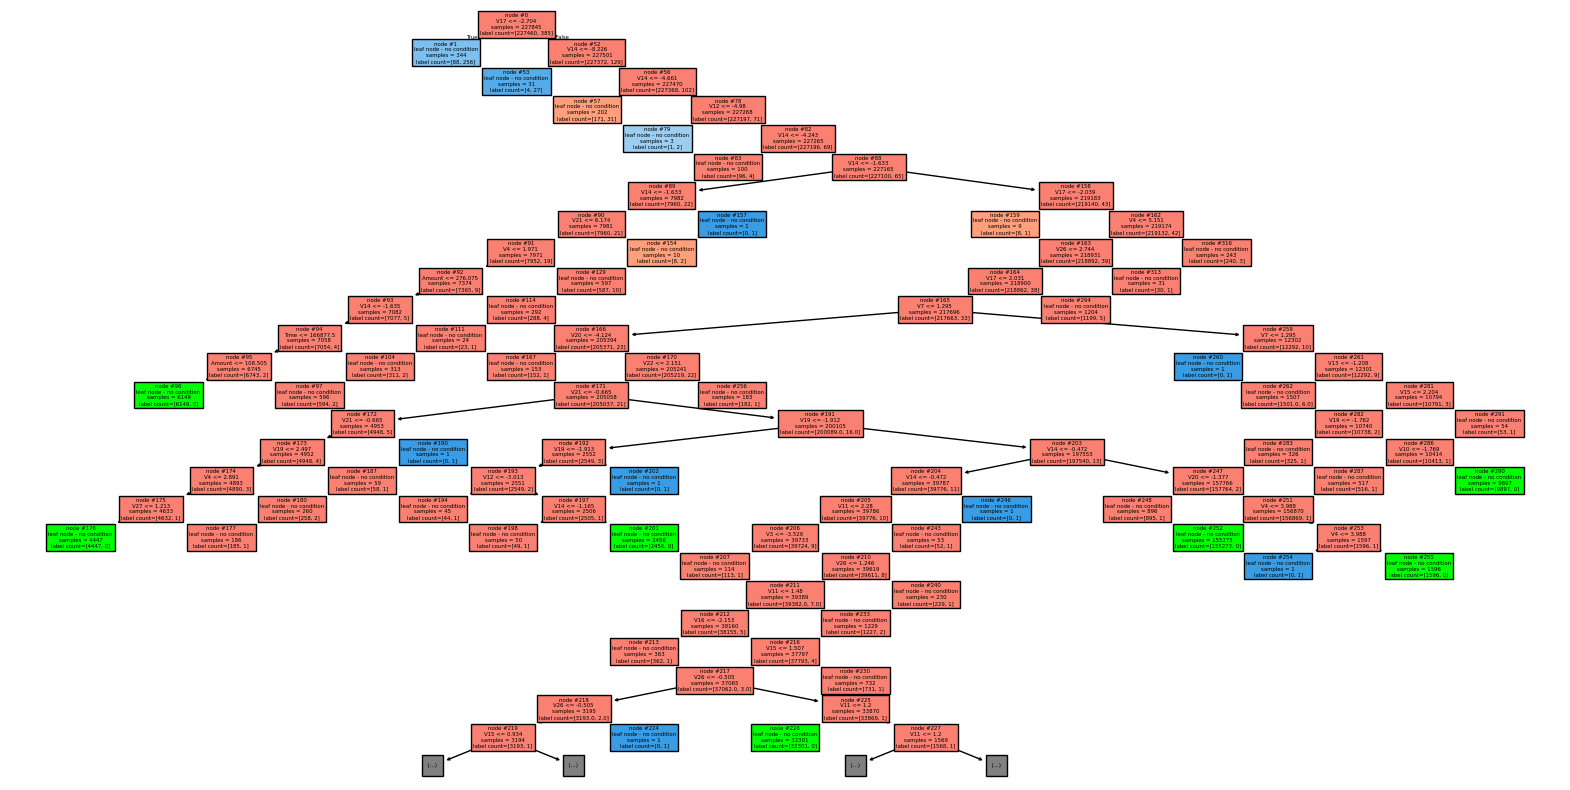

In [26]:
display_coreset(coretab_dt)

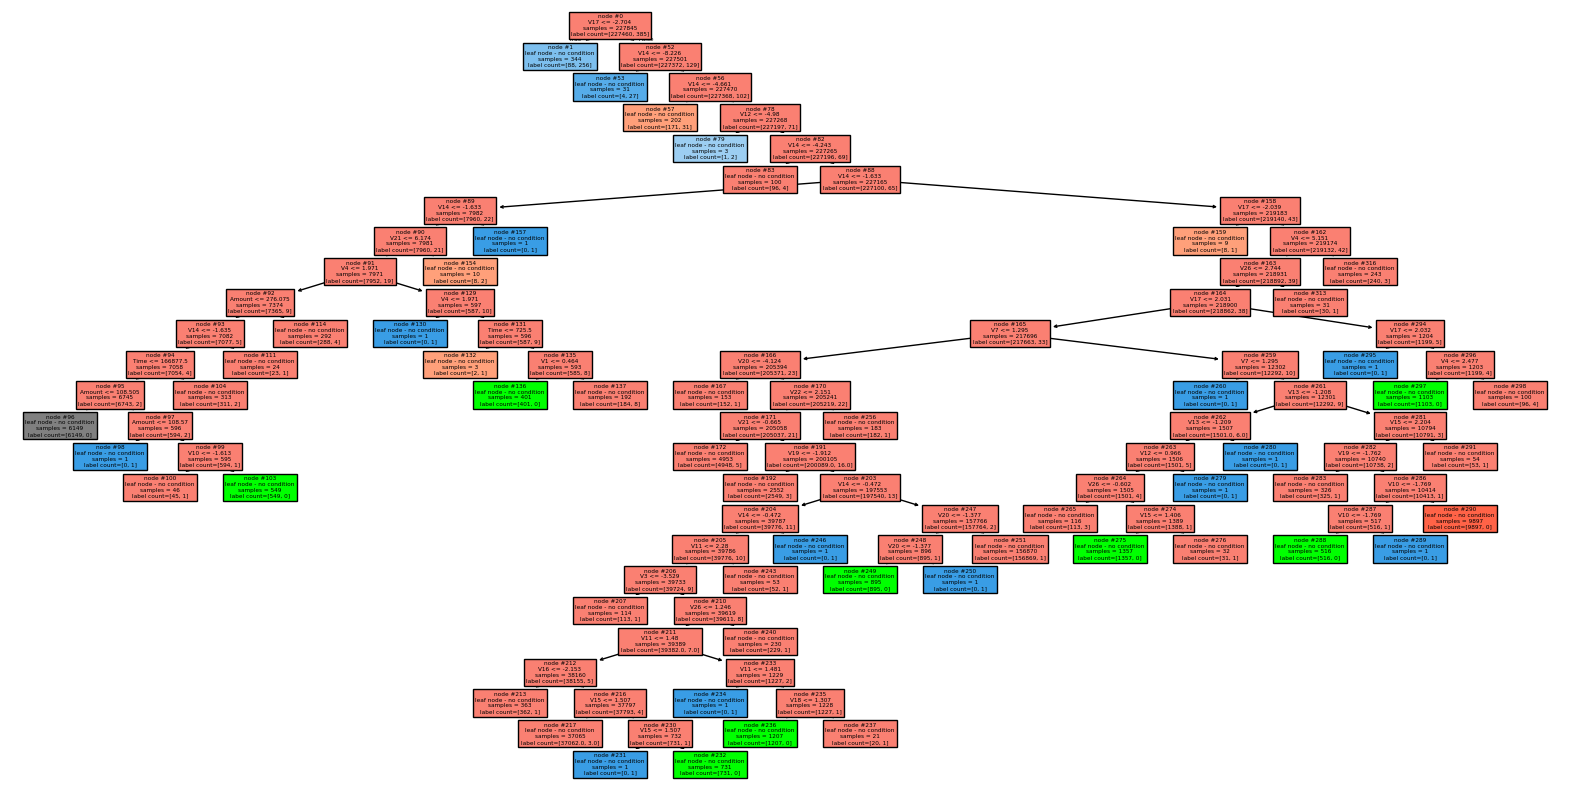

In [27]:
display_differences_coreset_with_nodes(coretab_dt, coreset_with_feature)